In [1]:
!pip install lime shap catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import lime
import lime.lime_tabular
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from google.colab import drive

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=a82a7258888398c3a79118bf66834ea7ca3f91b461bb99f310b4f7bc0440f088
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
# 1. Connect to Drive and Load Data
drive.mount('/content/drive')
df_clean = pd.read_csv('/content/drive/MyDrive/cardiovascular_ready_for_models.csv')

# 2. DEFINE X AND y (This was missing from your code!)
if 'CARDIO_DISEASE' in df_clean.columns:
    target_col = 'CARDIO_DISEASE'
elif 'target' in df_clean.columns:
    target_col = 'target'
else:
    target_col = df_clean.columns[-1] # Fallback to the last column

X = df_clean.drop(target_col, axis=1)
y = df_clean[target_col]

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Scale the Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing complete. Target column identified as:", target_col)
print("✅ Number of features for modeling:", X_train_scaled.shape[1])

Mounted at /content/drive
✅ Preprocessing complete. Target column identified as: CARDIO_DISEASE
✅ Number of features for modeling: 11


In [3]:
# 1. Define Base Learners (Layer 1) - Based on the "Good but Different" principle
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('mlp', MLPClassifier(max_iter=300, random_state=42, early_stopping=True)), # Optimized max_iter
    ('catboost', CatBoostClassifier(silent=True, random_state=42, task_type="GPU"))
]

In [4]:
# 2. Define Meta-Learner (Layer 2) - Paper uses Logistic Regression to avoid overfitting
meta_learner = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000)

In [5]:
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5
)

# 4. Train
print("Training Stacking Ensemble")
stack_model.fit(X_train_scaled, y_train)

Training Stacking Ensemble


StackingClassifier(cv=5,
                   estimators=[('rf',
                                RandomForestClassifier(n_jobs=-1,
                                                       random_state=42)),
                               ('et',
                                ExtraTreesClassifier(n_jobs=-1,
                                                     random_state=42)),
                               ('mlp',
                                MLPClassifier(early_stopping=True, max_iter=300,
                                              random_state=42)),
                               ('catboost',
                                CatBoostClassifier(random_state=42, silent=True, task_type='GPU'))],
                   final_estimator=LogisticRegression(max_iter=1000))

In [6]:
# 5. Evaluate
y_pred_stack = stack_model.predict(X_test_scaled)
print("--- Stacking Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_stack):.4f}")
print(f"AUC Score: {roc_auc_score(y_test, stack_model.predict_proba(X_test_scaled)[:, 1]):.4f}")

--- Stacking Model Results ---
Accuracy: 0.7388
AUC Score: 0.8072


Generating SHAP Summary Plot


  0%|          | 0/10 [00:00<?, ?it/s]

SHAP values shape: (10, 11)
Data shape: (10, 11)


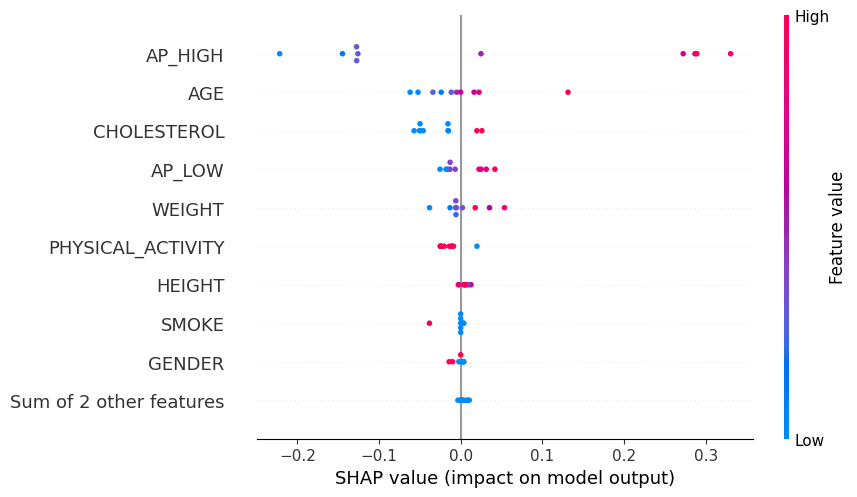

In [7]:
# Technique 1: SHAP (Corrected for Stacking Model)
print("Generating SHAP Summary Plot")
background = shap.sample(X_train_scaled, 50)
explainer_stack = shap.KernelExplainer(stack_model.predict_proba, background)
shap_values_list = explainer_stack.shap_values(X_test_scaled[:10])

if isinstance(shap_values_list, list):
    shap_values_array = np.array(shap_values_list[1])
else:
    shap_values_array = shap_values_list[:, :, 1]

if shap_values_array.ndim == 3:
    shap_values_array = shap_values_array[:, :, 1]

data_array = np.array(X_test_scaled[:10])

explanation = shap.Explanation(
    values=shap_values_array,
    data=data_array,
    feature_names=X.columns.tolist()
)
print(f"SHAP values shape: {shap_values_array.shape}")
print(f"Data shape: {data_array.shape}")
assert shap_values_array.shape == data_array.shape, \
    f"Shape mismatch: {shap_values_array.shape} vs {data_array.shape}"

shap.plots.beeswarm(explanation)

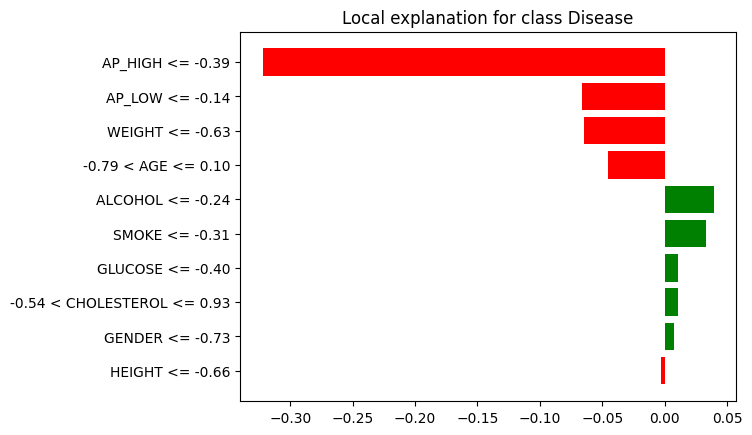

In [8]:
# Technique 2: LIME
lime_stack = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    mode='classification'
)
lime_stack.explain_instance(X_test_scaled[0], stack_model.predict_proba).as_pyplot_figure()
plt.show()

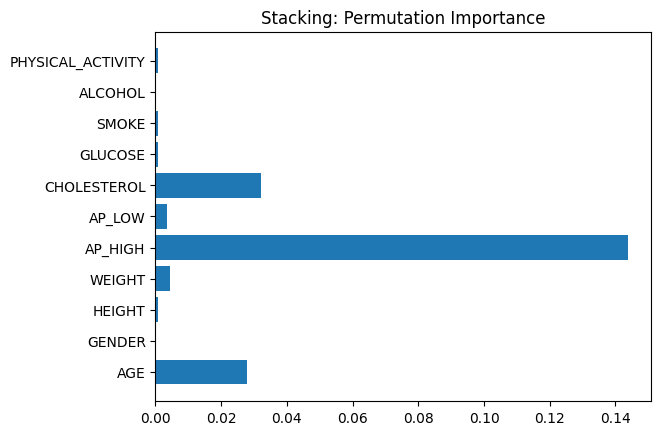

In [9]:
# Technique 3: Permutation Importance
result_stack = permutation_importance(stack_model, X_test_scaled, y_test, n_repeats=5, random_state=42)
plt.barh(X.columns, result_stack.importances_mean)
plt.title("Stacking: Permutation Importance")
plt.show()

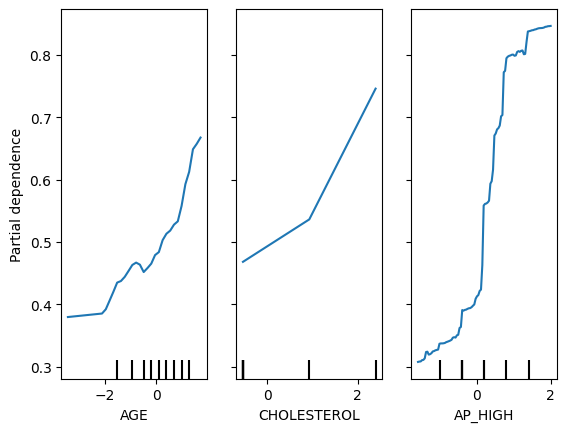

In [10]:
# Technique 4: Partial Dependence Plots (PDP)
features_to_plot = [col for col in ['AGE', 'CHOLESTEROL', 'AP_HIGH'] if col in X.columns]
PartialDependenceDisplay.from_estimator(stack_model, X_train_scaled, features_to_plot, feature_names=X.columns.tolist(), target=1)
plt.show()